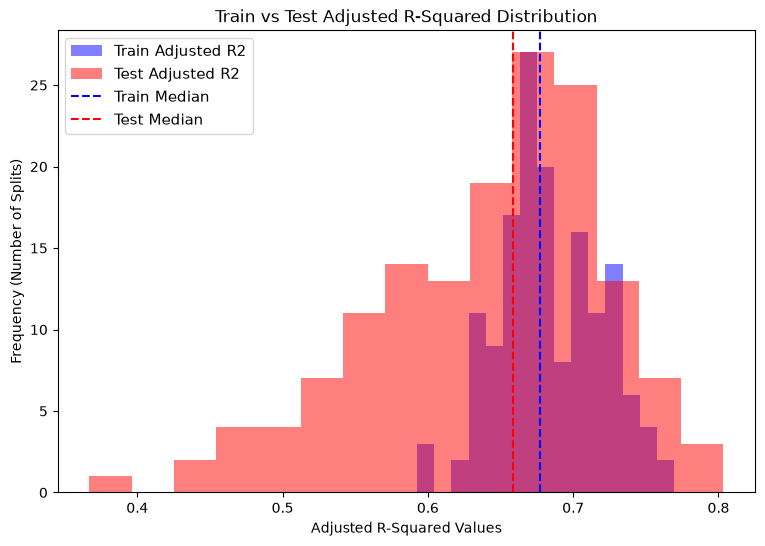

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score

# Verileri oku ve sırala
df = pd.read_csv('TScut_verisi.csv')
# Loglar hata vermesin diye 0dan büyük şartı
df = df[
    (df['LUMG'] > 0) & 
    (df['ECut_HYB'] > 0) & 
    (df['P'] > 0) & 
    (df['PdotCor'] > 0)
].copy()

# Log versiyonlarını kaydetme
df['L_log'] = np.log10(df['LUMG'])
df['P_log'] = np.log10(df['P'])
df['Pdot_log'] = np.log10(df['PdotCor'])
df['Ecut_log'] = np.log10(df['ECut_HYB'])

Y = df['L_log']
X = df [['P_log','Pdot_log','Ecut_log']]

# Rsquaredleri eklemek icin bos liste
R2_train = []
R2_test = []

# Train-Test Split
rkf = RepeatedKFold(n_splits=3, n_repeats=50, random_state=10)
for train_index, test_index in rkf.split(X):
    X_train = X.iloc[train_index]
    Y_train = Y.iloc[train_index]
    X_test = X.iloc[test_index]
    Y_test = Y.iloc[test_index]

    # Modeli ve fiti olusturma
    X_train = sm.add_constant(X_train)
    model = sm.OLS(Y_train , X_train).fit()
    R2_train.append(model.rsquared_adj)
    
    # Test setinden tahmin
    X_test = sm.add_constant(X_test)
    Y_tahmin = model.predict(X_test)
    # Normal Rkare degeri
    R2score_test = r2_score(Y_test, Y_tahmin)
    # Adjusted Rkare degeri
    n = len(Y_test)
    p = 3           # P, Pdot, Ecut
    R2score_test_adj = 1 - ((1 - R2score_test) * (n - 1) / (n - p - 1))
    R2_test.append(R2score_test_adj)


plt.figure(figsize = (9,6))
plt.hist(R2_train, bins=15, alpha=0.5, color='blue', label='Train Adjusted R2') #edgecolor='white')
plt.hist(R2_test, bins=15, alpha=0.5, color='red', label='Test Adjusted R2') #edgecolor='white')           
median_train = np.median(R2_train)
median_test = np.median(R2_test)
plt.axvline(median_train, color='blue', linestyle='--', label='Train Median')
plt.axvline(median_test, color='red', linestyle='--',label='Test Median')
plt.xlabel('Adjusted R-Squared Values')
plt.ylabel('Frequency (Number of Splits)')
plt.title('Train vs Test Adjusted R-Squared Distribution')
plt.legend(loc='upper left', fontsize=11)
plt.show()